# House Prices Prediction

Linear regression baseline for the Kaggle *House Prices: Advanced Regression Techniques* competition.

This notebook covers:
- exploratory analysis of `SalePrice`;
- missing value handling and feature preprocessing;
- target encoding for nominal features;
- ordinal encoding and numeric scaling;
- model evaluation with RMSE, R2, and bootstrap confidence intervals.


In [98]:
import pandas as pd
import seaborn as sns
import numpy as np
sns.set(rc={'figure.figsize': (11.7, 8.27)})
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from category_encoders.target_encoder import TargetEncoder
import warnings 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder


In [99]:
from pathlib import Path

DATA_DIR = Path.cwd() / 'data'
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd().parent / 'data'

data = pd.read_csv(DATA_DIR / 'train.csv')
data.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<Axes: xlabel='SalePrice', ylabel='Count'>

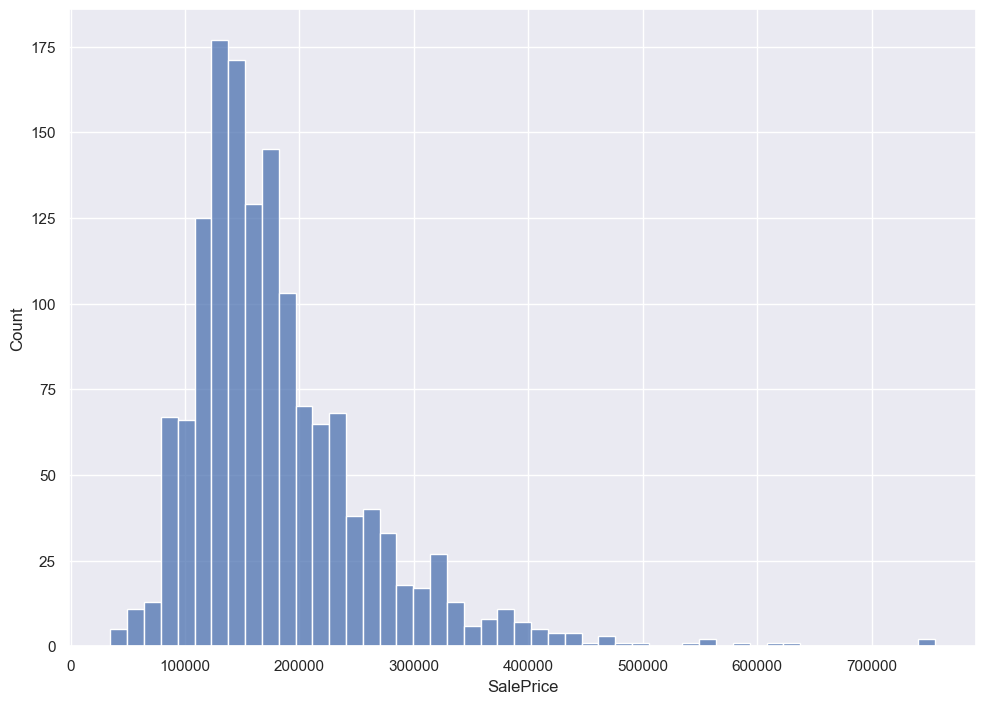

In [100]:
sns.histplot(data['SalePrice'])

In [102]:
data = data[data['SalePrice'] < 700000]


In [103]:
print(len(data))

1458


In [104]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

X_y_train = X_train.copy(deep=True)
X_y_train['SalePrice'] = y_train

In [105]:
pd.set_option('display.max_rows', None)
print(X_train.isna().sum().sort_values(ascending=False))

PoolQC           1162
MiscFeature      1118
Alley            1093
Fence             938
MasVnrType        713
FireplaceQu       552
LotFrontage       213
GarageCond         62
GarageType         62
GarageYrBlt        62
GarageQual         62
GarageFinish       62
BsmtFinType2       31
BsmtExposure       31
BsmtFinType1       30
BsmtCond           30
BsmtQual           30
MasVnrArea          7
Electrical          1
BedroomAbvGr        0
KitchenAbvGr        0
Functional          0
TotRmsAbvGrd        0
HalfBath            0
FullBath            0
BsmtHalfBath        0
BsmtFullBath        0
KitchenQual         0
Id                  0
Fireplaces          0
LowQualFinSF        0
GarageCars          0
GarageArea          0
PavedDrive          0
WoodDeckSF          0
OpenPorchSF         0
EnclosedPorch       0
3SsnPorch           0
ScreenPorch         0
PoolArea            0
MiscVal             0
MoSold              0
YrSold              0
SaleType            0
GrLivArea           0
HeatingQC 

In [106]:
# === 1. ОБРАБОТКА ПРОПУСКОВ ===

# Категориальные признаки - заполняем 'None' (отсутствие объекта)
none_fill_cols = [
    'Alley',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature',
    'MasVnrType'  
]

for col in none_fill_cols:
    X_train[col] = X_train[col].fillna('None')
    X_test[col] = X_test[col].fillna('None')

# Числовые признаки - заполняем 0 (отсутствие объекта)
zero_fill_cols = [
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'BsmtFullBath',
    'BsmtHalfBath',
    'GarageCars',
    'GarageArea',
    'PoolArea',
    'Fireplaces',
    'MasVnrArea'
]

for col in zero_fill_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

# Специфичная обработка отдельных признаков

# LotFrontage - медиана (ВАЖНО: используем медиану из train для test)
lotfrontage_median = X_train['LotFrontage'].median()
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(lotfrontage_median)
X_test['LotFrontage'] = X_test['LotFrontage'].fillna(lotfrontage_median)

X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(X_train['YearBuilt'])
X_test['GarageYrBlt'] = X_test['GarageYrBlt'].fillna(X_test['YearBuilt'])

# Electrical - мода
electrical_mode = X_train['Electrical'].mode()[0]
X_train['Electrical'] = X_train['Electrical'].fillna(electrical_mode)
X_test['Electrical'] = X_test['Electrical'].fillna(electrical_mode)

# MSZoning - ДОБАВЛЕНО (может быть пропуски)
if X_train['MSZoning'].isna().any():
    mszoning_mode = X_train['MSZoning'].mode()[0]
    X_train['MSZoning'] = X_train['MSZoning'].fillna(mszoning_mode)
    X_test['MSZoning'] = X_test['MSZoning'].fillna(mszoning_mode)

# Utilities - ДОБАВЛЕНО (обычно все 'AllPub')
if X_train['Utilities'].isna().any():
    utilities_mode = X_train['Utilities'].mode()[0]
    X_train['Utilities'] = X_train['Utilities'].fillna(utilities_mode)
    X_test['Utilities'] = X_test['Utilities'].fillna(utilities_mode)

# Functional - ДОБАВЛЕНО (на случай пропусков)
if X_train['Functional'].isna().any():
    functional_mode = X_train['Functional'].mode()[0]
    X_train['Functional'] = X_train['Functional'].fillna(functional_mode)
    X_test['Functional'] = X_test['Functional'].fillna(functional_mode)

# SaleType - ДОБАВЛЕНО (на случай пропусков)
if X_train['SaleType'].isna().any():
    saletype_mode = X_train['SaleType'].mode()[0]
    X_train['SaleType'] = X_train['SaleType'].fillna(saletype_mode)
    X_test['SaleType'] = X_test['SaleType'].fillna(saletype_mode)

# KitchenQual - ДОБАВЛЕНО (на случай пропусков)
if X_train['KitchenQual'].isna().any():
    kitchenqual_mode = X_train['KitchenQual'].mode()[0]
    X_train['KitchenQual'] = X_train['KitchenQual'].fillna(kitchenqual_mode)
    X_test['KitchenQual'] = X_test['KitchenQual'].fillna(kitchenqual_mode)

# === 2. ПРОВЕРКА ===
pd.set_option('display.max_rows', None)
print("Пропуски после обработки в TRAIN:")
print(X_train.isna().sum().sort_values(ascending=False))
print("\nПропуски после обработки в TEST:")
print(X_test.isna().sum().sort_values(ascending=False))




Пропуски после обработки в TRAIN:
Id               0
MSSubClass       0
GarageType       0
FireplaceQu      0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
KitchenQual      0
KitchenAbvGr     0
BedroomAbvGr     0
HalfBath         0
FullBath         0
BsmtHalfBath     0
BsmtFullBath     0
GrLivArea        0
LowQualFinSF     0
2ndFlrSF         0
1stFlrSF         0
Electrical       0
GarageYrBlt      0
GarageFinish     0
GarageCars       0
PoolArea         0
SaleType         0
YrSold           0
MoSold           0
MiscVal          0
MiscFeature      0
Fence            0
PoolQC           0
ScreenPorch      0
GarageArea       0
3SsnPorch        0
EnclosedPorch    0
OpenPorchSF      0
WoodDeckSF       0
PavedDrive       0
GarageCond       0
GarageQual       0
CentralAir       0
HeatingQC        0
Heating          0
LotConfig        0
OverallQual      0
HouseStyle       0
BldgType         0
Condition2       0
Condition1       0
Neighborhood     0
LandSlope        0
Utilities       

<Axes: >

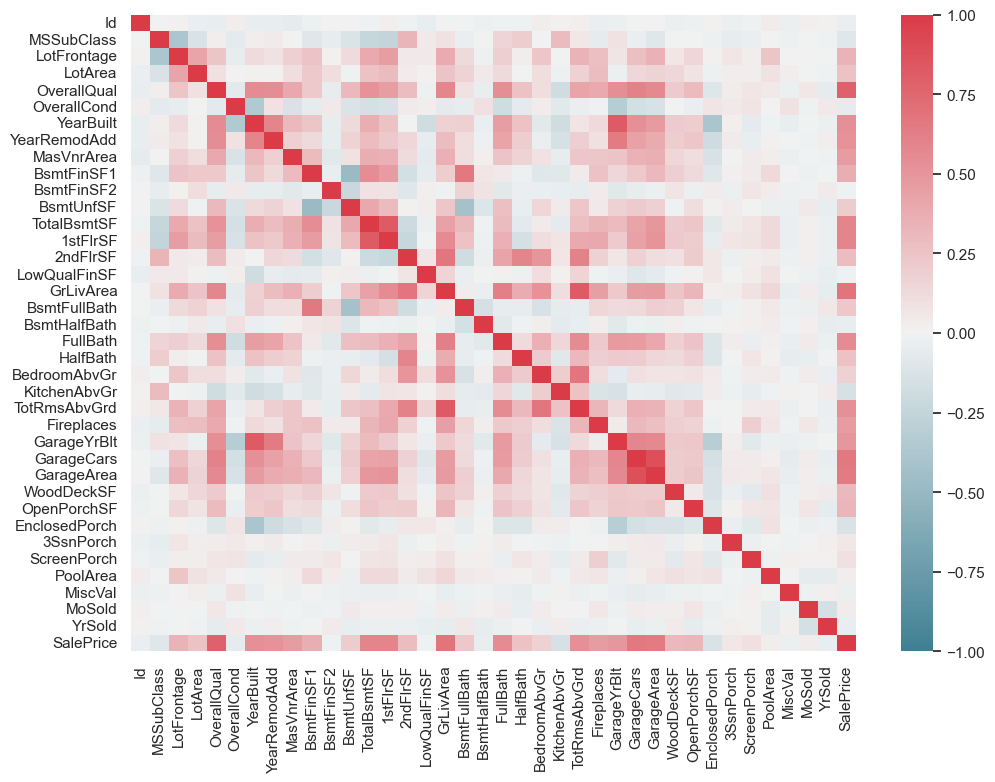

In [107]:
sns.heatmap(X_y_train.corr(numeric_only=True),
            vmin=-1, vmax=1,
            cmap=sns.diverging_palette(220, 10, as_cmap=True))

In [108]:
numeric_features = ["LotFrontage", "LotArea","YearBuilt", "YearRemodAdd","MasVnrArea","BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF","1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea","BsmtFullBath", "BsmtHalfBath",
    "FullBath", "HalfBath","BedroomAbvGr", "KitchenAbvGr","TotRmsAbvGrd","Fireplaces","GarageYrBlt", "GarageCars", "GarageArea","WoodDeckSF", "OpenPorchSF", "EnclosedPorch","3SsnPorch", "ScreenPorch","PoolArea",
    "MiscVal", "MoSold", "YrSold"
]
ordinal_features = ["LotShape","LandSlope","OverallQual","OverallCond","ExterQual","ExterCond","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1",
    "BsmtFinType2","HeatingQC","KitchenQual","Functional","FireplaceQu","GarageFinish","GarageQual","GarageCond","PoolQC","Fence",
    "PavedDrive"
]
categorical_features = ["MSSubClass","MSZoning","Street","Alley","LandContour","Utilities","LotConfig","Neighborhood","Condition1","Condition2",
    "BldgType","HouseStyle","RoofStyle","RoofMatl","Exterior1st","Exterior2nd","MasVnrType","Foundation","Heating","CentralAir",
    "Electrical","GarageType","MiscFeature","SaleType","SaleCondition"
]


In [109]:
# отберем интересные numeric_features

corr_df = X_y_train[numeric_features + ['SalePrice']]
corry = corr_df.corr()['SalePrice']

main_numeric_features = (
    corry[(corry > 0.3) | (corry < -0.3)]
    .drop('SalePrice')
    .index
    .tolist()
)
print(len(numeric_features), len(main_numeric_features))
print(main_numeric_features)


33 16
['LotFrontage', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF']


In [110]:
# соберем интересные ordinal_features
main_ordinal_features = []
for fact in ordinal_features:
    taby = X_y_train.groupby(fact, as_index=False).agg({'SalePrice': 'mean'})['SalePrice']
    if abs(min(taby) - max(taby)) > 70000:
        main_ordinal_features.append(fact)
print(len(ordinal_features),len(main_ordinal_features))
print(main_ordinal_features)
        

21 16
['LotShape', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond']


In [111]:
# соберем интересные categorical_features
main_categorical_features = []
for fact in categorical_features:
    taby = X_y_train.groupby(fact, as_index=False).agg({'SalePrice': 'mean'})['SalePrice']
    if abs(min(taby) - max(taby)) > 70000:
        main_categorical_features.append(fact)
print(len(categorical_features),len(main_categorical_features))
print(main_categorical_features)


25 18
['MSSubClass', 'MSZoning', 'Neighborhood', 'Condition1', 'Condition2', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']


In [112]:
main_numeric_features = numeric_features
main_ordinal_features = ordinal_features
main_categorical_features = categorical_features


In [113]:
print(len(numeric_features) + len(ordinal_features) + len(categorical_features))
selected_features = main_numeric_features + main_ordinal_features + main_categorical_features
X_train = X_train[selected_features].copy()
X_test  = X_test[selected_features].copy()

79


In [114]:
# приступим к обработке категориальных факторов:
te = TargetEncoder(cols=main_categorical_features, smoothing=20.0)
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)


In [115]:
# приступим к обработке порядковых факторов
ord_cols = [c for c in main_ordinal_features if X_train[c].dtype == 'object']

for col in ord_cols:
    # 1. Получаем уникальные категории из train (сортируем для стабильности)
    categories = sorted(X_train[col].dropna().unique())
    # 2. Создаём маппинг: категория → номер (начиная с 1)
    mapping = {cat: i+1 for i, cat in enumerate(categories)}
    # 3. Применяем к train и test (неизвестные в test → -1)
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping).fillna(-1)



In [116]:
# приступим к обработке численных факторов 
from sklearn.preprocessing import MinMaxScaler

# Создаём объект scaler
scaler = MinMaxScaler()

# Обучаем на TRAIN и применяем к TRAIN
X_train[main_numeric_features] = scaler.fit_transform(X_train[main_numeric_features])

# Применяем тот же scaler к TEST (только transform!)
X_test[main_numeric_features] = scaler.transform(X_test[main_numeric_features])

In [117]:
print("NaN в train:", X_train.isna().sum().sum())
print("NaN в test :", X_test.isna().sum().sum())

NaN в train: 0
NaN в test : 0


In [118]:
X_train.head()

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,Exterior2nd,MasVnrType,Foundation,Heating,CentralAir,Electrical,GarageType,MiscFeature,SaleType,SaleCondition
1171,0.188356,0.035754,0.623188,0.133333,0.0,0.117293,0.000000,0.292766,0.206383,0.212712,...,147245.731944,155602.159888,149738.575343,179429.601583,183551.98895,184145.658168,200725.858198,158401.752054,170646.446955,172623.880333
75,0.000000,0.000557,0.731884,0.383333,0.0,0.081857,0.000000,0.000000,0.075614,0.044057,...,212606.219202,155602.159888,149738.575343,179429.601583,183551.98895,184145.658168,238253.517291,179492.346154,170646.446955,172623.880333
390,0.099315,0.032409,0.202899,0.000000,0.0,0.042700,0.265265,0.111926,0.140917,0.143873,...,147245.731944,155602.159888,134849.177432,179429.601583,183551.98895,184145.658168,135364.630753,179492.346154,170646.446955,172623.880333
1284,0.099315,0.038177,0.340580,0.666667,0.0,0.000000,0.000000,0.392962,0.131588,0.313217,...,155554.899587,155602.159888,221520.994010,179429.601583,183551.98895,184145.658168,135364.630753,179492.346154,170646.446955,172623.880333
682,0.160959,0.006596,0.898551,0.783333,0.0,0.177711,0.000000,0.140762,0.211293,0.219596,...,145292.652041,155602.159888,221520.994010,179429.601583,183551.98895,184145.658168,200725.858198,179492.346154,170646.446955,172623.880333


In [119]:
# создание модели 
model = LinearRegression()
model.fit(X_train, y_train)
# предсказания
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# метрики
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

print(f"RMSE train: ${rmse_train:,.0f}")
print(f"RMSE test : ${rmse_test:,.0f}")
print(f"R2  train : {r2_train:.4f}")
print(f"R2  test  : {r2_test:.4f}")

RMSE train: $26,813
RMSE test : $31,389
R2  train : 0.8710
R2  test  : 0.8589


In [120]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Подготовка данных для бутстрепа (если ещё не сделано)
# Убедись, что X_test — финальные признаки, y_test — цены
# ------------------------------------------------------------
X_test_final = X_test.copy()           # уже масштабирован, всё в числах
y_test_final = y_test.copy()

# Объединяем в один DataFrame для удобного сэмплирования
df_test = X_test_final.copy()
df_test['SalePrice'] = y_test_final

# ------------------------------------------------------------
# 2. Бутстреп
# ------------------------------------------------------------
n_iter = 1000
rmse_scores = []
r2_scores   = []

for i in range(n_iter):
    # Сэмплируем с возвращением (того же размера, что и тест)
    sample = df_test.sample(n=len(df_test), replace=True, random_state=i)
    
    X_sampled = sample.drop(columns=['SalePrice'])
    y_sampled = sample['SalePrice']
    
    # Предсказание (модель уже обучена)
    y_pred = model.predict(X_sampled)
    
    # Метрики
    rmse = np.sqrt(mean_squared_error(y_sampled, y_pred))
    r2   = r2_score(y_sampled, y_pred)
    
    rmse_scores.append(rmse)
    r2_scores.append(r2)

# ------------------------------------------------------------
# 3. 95% доверительные интервалы (перцентильный метод)
# ------------------------------------------------------------
rmse_ci = np.percentile(rmse_scores, [2.5, 97.5])
r2_ci   = np.percentile(r2_scores,   [2.5, 97.5])

print(f"RMSE 95% CI: ${rmse_ci[0]:,.0f} – ${rmse_ci[1]:,.0f}")
print(f"R²   95% CI: {r2_ci[0]:.4f} – {r2_ci[1]:.4f}")

RMSE 95% CI: $25,921 – $36,823
R²   95% CI: 0.8248 – 0.8904
